In [ ]:
import socket

# Bits lab Hostname
hostname = socket.gethostname()
print('Hostname: ',hostname)

# Student ID
username ='2025AC05348'
print('Student ID: ', username)

Hostname:  6c2ea214010c
Student ID:  2025AC05348


In [ ]:
#!pip install ucimlrepo

import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

## Dataset Description

The **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository is used for this classification task.

- **Number of instances:** 30,000
- **Number of features:** 23
- **Target variable:** `Y` — default payment next month
- **Classification type:** Binary classification
- **Class 0:** 23,364 instances
- **Class 1:** 6,636 instances

The objective is to predict whether a credit-card client will default on the next month's payment based on the client's demographic, credit, payment-status, bill-amount, and previous-payment information.

In [ ]:
#Feature groups
categorical_features = ["X2", "X3", "X4"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['X2', 'X3', 'X4']
Numerical features: ['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


In [ ]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
# Flatten target
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

Training set: (24000, 23)
Testing set: (6000, 23)


In [ ]:
# Preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features)
    ]
)

In [ ]:
# Transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (24000, 33)
Processed testing shape: (6000, 33)


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)

y_pred_dt = decision_tree_model.predict(X_test_processed)
y_prob_dt = decision_tree_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_model.predict(X_test_processed)
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train_processed, y_train)

y_pred_nb = naive_bayes_model.predict(X_test_processed)
y_prob_nb = naive_bayes_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_processed, y_train)

y_pred_rf = random_forest_model.predict(X_test_processed)
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr, y_prob_lr),
    "Decision Tree": evaluate_model(y_test, y_pred_dt, y_prob_dt),
    "KNN": evaluate_model(y_test, y_pred_knn, y_prob_knn),
    "Naive Bayes": evaluate_model(y_test, y_pred_nb, y_prob_nb),
    "Random Forest": evaluate_model(y_test, y_pred_rf, y_prob_rf)
}

results_df = pd.DataFrame(results).T

results_df_rounded = results_df.round(4)

results_df_rounded

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.8088,0.7100,0.6923,0.2442,0.3610,0.3302
Decision Tree,0.7185,0.6055,0.3731,0.4009,0.3865,0.2044
KNN,0.7948,0.7040,0.5561,0.3587,0.4361,0.3292
Naive Bayes,0.2903,0.7240,0.2340,0.9714,0.3771,0.1034
Random Forest,0.8105,0.7592,0.6243,0.3595,0.4562,0.3711


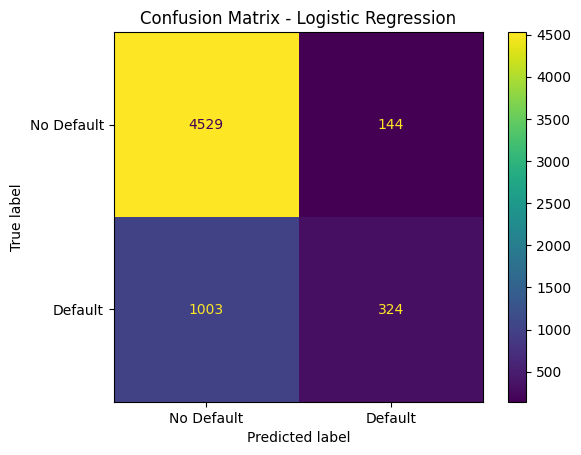

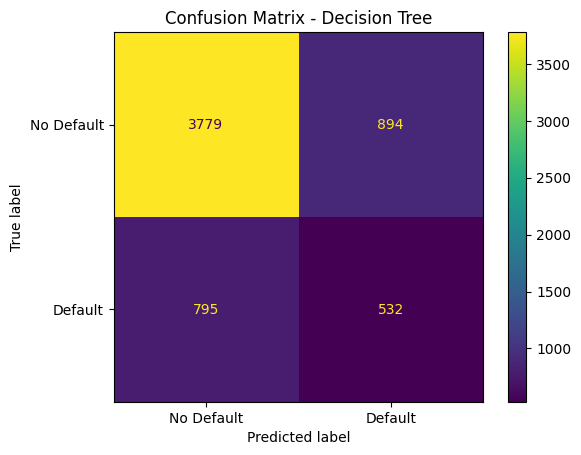

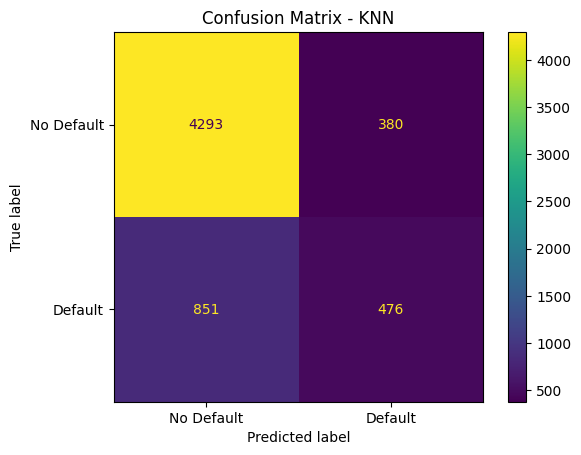

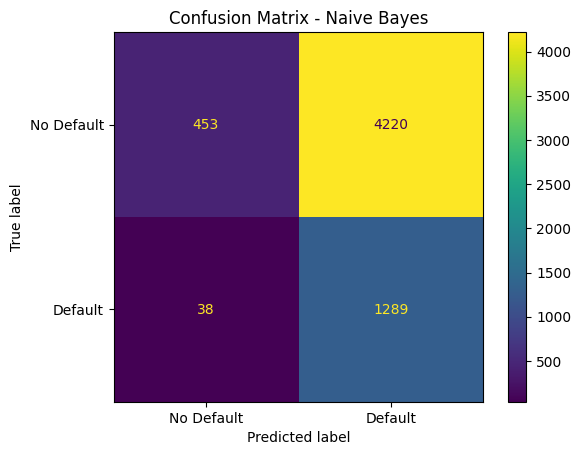

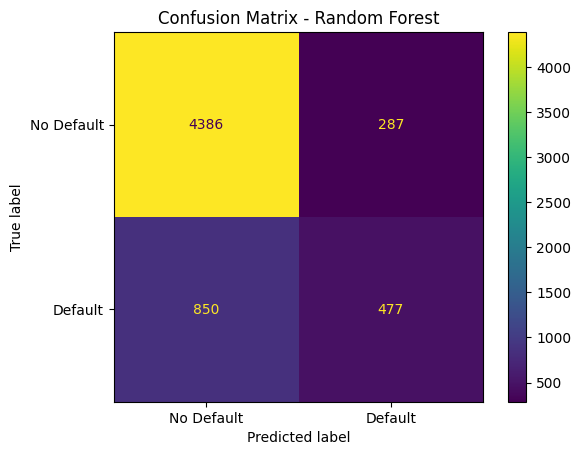

In [ ]:
# Confusion matrices
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf
}

for model_name, predictions in model_predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No Default", "Default"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

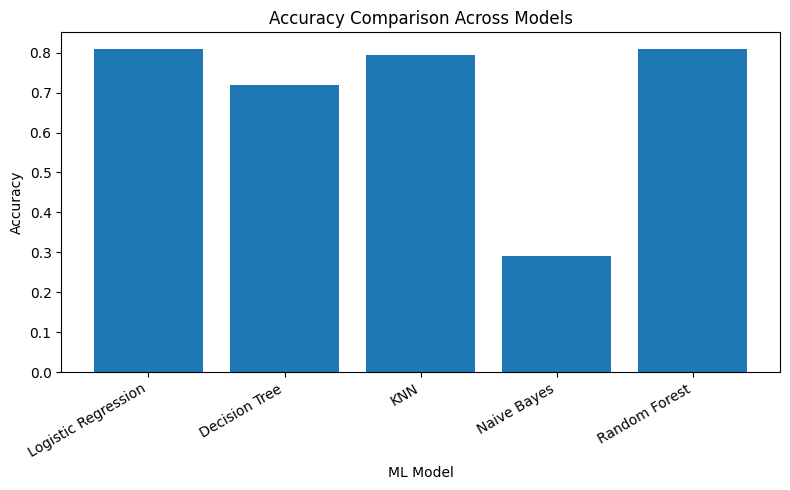

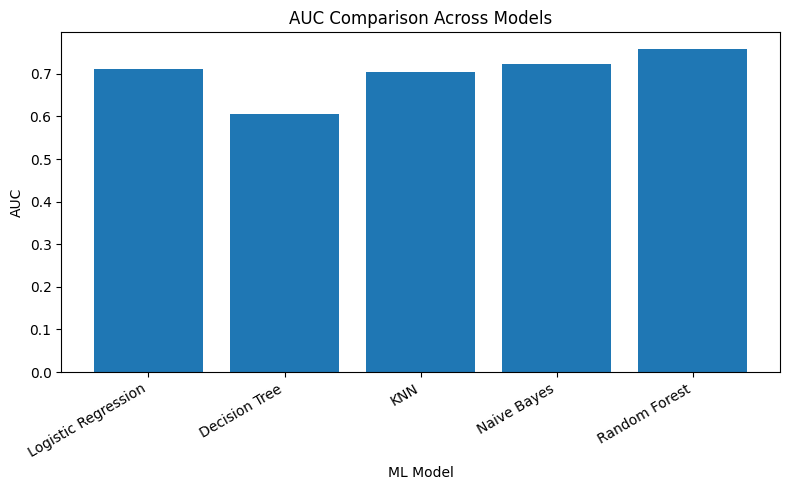

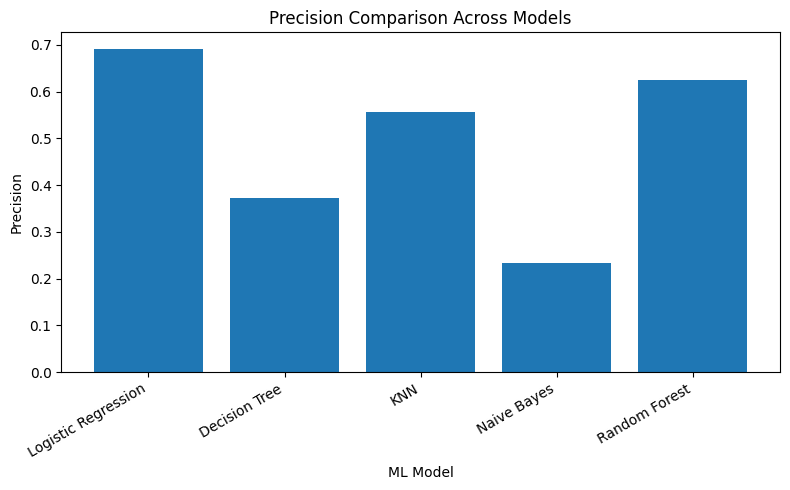

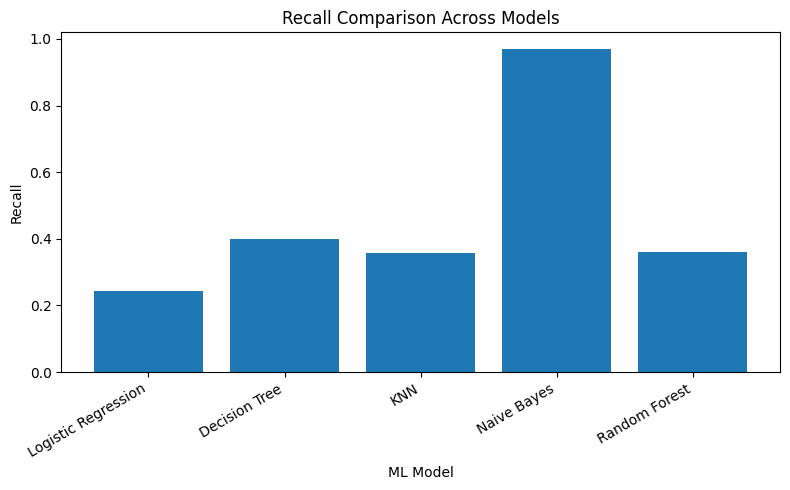

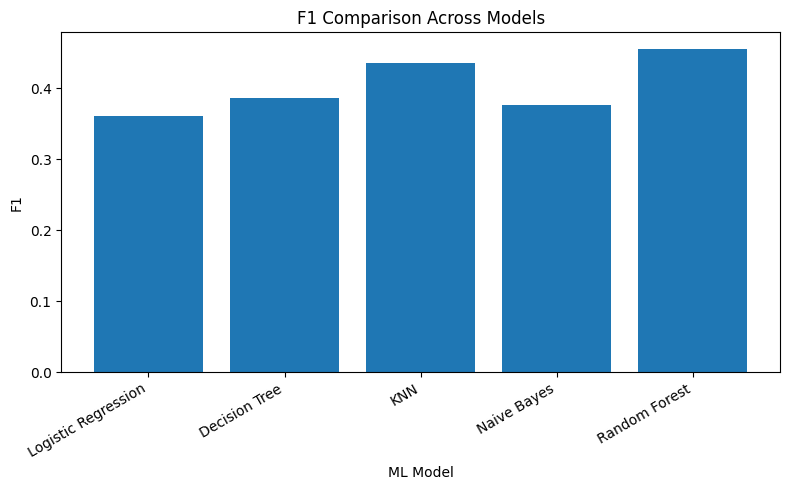

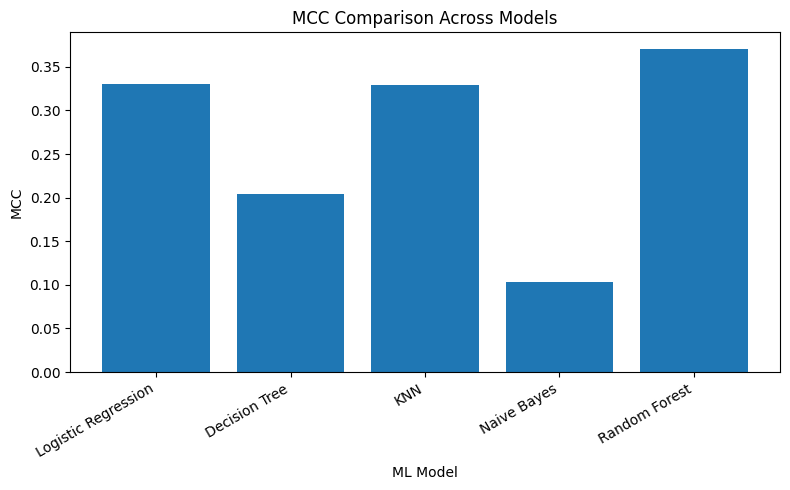

In [ ]:
# Model performance comparison
import matplotlib.pyplot as plt

metrics = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    plt.bar(results_df.index, results_df[metric])

    plt.title(f"{metric} Comparison Across Models")
    plt.xlabel("ML Model")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

## Model Evaluation and Observations

Five classification models were implemented and evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

### Model Observations

| ML Model | Observation |
|---|---|
| **Logistic Regression** | Achieved an accuracy of 0.8088 and the highest precision of 0.6923. However, its recall of 0.2442 indicates that it missed a significant number of actual defaulters. |
| **Decision Tree** | Achieved an accuracy of 0.7185 and an AUC of 0.6055. It identified more actual defaulters than Logistic Regression but produced more false positives, resulting in lower overall performance. |
| **KNN** | Achieved an accuracy of 0.7948 and an F1 score of 0.4361. It provided moderate and relatively balanced performance but remained below Random Forest on the overall evaluation metrics. |
| **Naive Bayes** | Achieved the highest recall of 0.9714, identifying almost all actual defaulters. However, its precision of 0.2339 and accuracy of 0.2903 were low because it generated a large number of false-positive predictions. |
| **Random Forest** | Achieved the highest accuracy (0.8105), AUC (0.7592), F1 score (0.4562), and MCC (0.3711). It provided the best overall balance among the evaluated models. |

### Overall Winner

**Random Forest** was the overall best-performing model for this dataset. It achieved the highest values for four of the six evaluation metrics: Accuracy, AUC, F1 Score, and MCC. Although Logistic Regression achieved higher precision and Naive Bayes achieved higher recall, Random Forest provided the strongest overall balance across the evaluation metrics.

In [ ]:
import sys
import sklearn
import numpy
import scipy
import joblib
import pandas

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Joblib:", joblib.__version__)
print("Pandas:", pandas.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
NumPy: 2.0.2
SciPy: 1.16.3
Joblib: 1.5.3
Pandas: 2.2.2
